# Exploratory Data Analysis

In [1]:
import pandas as pd
from data_profiling import ProfileReport   

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


![Alt text][image-ref]

[image-ref]: /workspaces/codespaces-blank/home-credit-risk/data/home_credit.png "Optional Title"   

In [2]:
app_train = pd.read_csv('../data/application_train.csv')
app_test = pd.read_csv('../data/application_test.csv')

In [3]:
app_train.shape

(307511, 122)

In [4]:
app_train.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


sk_id_curr is applicant identifier. Lets check if it's same as len(train)

In [5]:
print(len(app_train))
print(app_train['SK_ID_CURR'].nunique())

307511
307511


In [6]:
print(app_train['TARGET'].value_counts())
print(app_train['TARGET'].value_counts(normalize=True)*100)

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


TARGET is imbalanced. Modeling, validation and evaluation must address this.

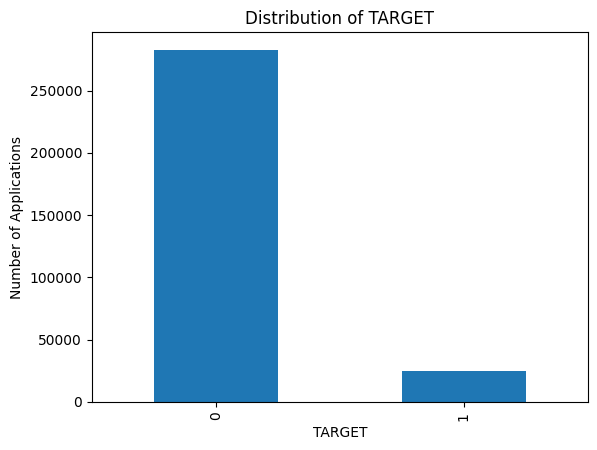

In [7]:
import matplotlib.pyplot as plt

app_train["TARGET"].value_counts().plot(kind="bar")

plt.title("Distribution of TARGET")
plt.xlabel("TARGET")
plt.ylabel("Number of Applications")
plt.show()

In [8]:
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [9]:
import numpy as np
categorical_columns = app_train.select_dtypes(include=['object']).columns
numerical_columns = app_train.select_dtypes(include=np.number).columns
len(numerical_columns), len(categorical_columns)

(106, 16)

In [10]:
description = pd.read_csv(
    "/workspaces/codespaces-blank/home-credit-risk/data/HomeCredit_columns_description.csv",
    encoding="latin1"
)

description[
    description["Row"] == "EXT_SOURCE_1"
]

,Unnamed: 0,Table,Row,Description,Special
41,44,application_{train|test}.csv,EXT_SOURCE_1,Normalized score from external data source,normalized


In [11]:
missing = app_train.isnull().sum()

missing_pct = (
    app_train.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct.head(30)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
BASEMENTAREA_MODE           58.515956
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

In [12]:
app_train.groupby(
    app_train["EXT_SOURCE_1"].isnull()
)["TARGET"].mean()

EXT_SOURCE_1
False    0.074955
True     0.085195
Name: TARGET, dtype: float64

In [17]:
app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [18]:
app_train["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [19]:
app_train.groupby("TARGET")["AMT_INCOME_TOTAL"].median()

TARGET
0    148500.0
1    135000.0
Name: AMT_INCOME_TOTAL, dtype: float64

In [20]:
app_train.groupby("TARGET")["AMT_INCOME_TOTAL"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.0,169077.722266,110476.268524,25650.0,112500.0,148500.0,202500.0,18000090.0
1,24825.0,165611.760906,746676.959440,25650.0,112500.0,135000.0,202500.0,117000000.0


In [13]:
# # ============================================================
# # HOME CREDIT — COLUMN GROUPS FOR EDA
# # ============================================================

# # 1. ID / TARGET
# # Identifies each loan/application and tells us whether the
# # applicant experienced payment difficulties (TARGET).
# id_cols = [
#     "SK_ID_CURR",     # Unique ID of the loan/application
#     "TARGET",         # 1 = payment difficulties/default, 0 = no payment difficulties
# ]


# # 2. LOAN / FINANCIAL
# # Describes the loan itself and the applicant's financial
# # capacity: income, loan amount, repayment amount, and goods price.
# financial_cols = [
#     "NAME_CONTRACT_TYPE",   # Type of loan contract, e.g. Cash loans / Revolving loans
#     "AMT_INCOME_TOTAL",     # Applicant's total income
#     "AMT_CREDIT",           # Total amount of credit/loan given
#     "AMT_ANNUITY",          # Periodic (usually monthly) loan repayment amount
#     "AMT_GOODS_PRICE",      # Price of the goods/property being financed
# ]


# # 3. DEMOGRAPHICS / FAMILY
# # Describes the applicant's personal, demographic, education,
# # and family situation.
# demographic_cols = [
#     "CODE_GENDER",              # Gender of the applicant
#     "CNT_CHILDREN",             # Number of children
#     "DAYS_BIRTH",               # Age represented as negative number of days
#     "NAME_FAMILY_STATUS",       # Marital/family status
#     "CNT_FAM_MEMBERS",          # Number of family members
#     "NAME_EDUCATION_TYPE",      # Highest education level
#     "NAME_TYPE_SUITE",          # Who accompanied the applicant during application
# ]


# # 4. EMPLOYMENT / INCOME SOURCE
# # Describes where the applicant gets income from and their
# # employment situation.
# employment_cols = [
#     "NAME_INCOME_TYPE",         # Main source/type of income
#     "OCCUPATION_TYPE",          # Applicant's occupation/job category
#     "DAYS_EMPLOYED",            # Number of days employed; negative value means days before application
#     "ORGANIZATION_TYPE",        # Type of organization/industry where applicant works
# ]


# # 5. HOUSING / OWNERSHIP
# # Describes the applicant's assets and living arrangement,
# # such as car ownership, property ownership, and housing type.
# housing_cols = [
#     "FLAG_OWN_CAR",             # Whether applicant owns a car (Y/N)
#     "OWN_CAR_AGE",              # Age of applicant's car in years
#     "FLAG_OWN_REALTY",          # Whether applicant owns real estate/property (Y/N)
#     "NAME_HOUSING_TYPE",        # Type of housing where applicant lives
# ]


# # 6. REGION / GEOGRAPHY
# # Describes the applicant's geographical location and whether
# # their home and workplace are in different regions/cities.
# region_cols = [
#     "REGION_POPULATION_RELATIVE",       # Population of applicant's region relative to the country
#     "REGION_RATING_CLIENT",             # Rating of applicant's region
#     "REGION_RATING_CLIENT_W_CITY",      # Region rating considering the city
#     "REG_REGION_NOT_LIVE_REGION",       # Home region differs from registered region
#     "REG_REGION_NOT_WORK_REGION",       # Work region differs from registered region
#     "LIVE_REGION_NOT_WORK_REGION",      # Living region differs from work region
#     "REG_CITY_NOT_LIVE_CITY",           # Registered city differs from living city
#     "REG_CITY_NOT_WORK_CITY",           # Registered city differs from work city
#     "LIVE_CITY_NOT_WORK_CITY",          # Living city differs from work city
# ]


# # 7. APPLICATION TIMING / BEHAVIOR
# # Describes when the loan application was submitted.
# # Can sometimes capture application patterns or operational behavior.
# application_behavior_cols = [
#     "WEEKDAY_APPR_PROCESS_START",   # Day of the week when application started
#     "HOUR_APPR_PROCESS_START",      # Hour of the day when application started
# ]


# # 8. CONTACT / PHONE
# # Describes whether the applicant has provided/registered
# # different contact methods and when their phone information changed.
# contact_cols = [
#     "FLAG_MOBIL",               # Whether applicant provided a mobile phone
#     "FLAG_EMP_PHONE",           # Whether applicant provided an employer phone
#     "FLAG_WORK_PHONE",          # Whether applicant has a work phone
#     "FLAG_CONT_MOBILE",         # Whether contact information/mobile is reachable
#     "FLAG_PHONE",               # Whether applicant provided a phone number
#     "FLAG_EMAIL",               # Whether applicant provided an email address
#     "DAYS_LAST_PHONE_CHANGE",   # Days since the applicant last changed phone number
# ]


# # 9. EXTERNAL CREDIT SCORES
# # Credit scores obtained from external sources/bureaus.
# # These are often among the strongest predictors of default.
# external_score_cols = [
#     "EXT_SOURCE_1",             # External credit score from source 1
#     "EXT_SOURCE_2",             # External credit score from source 2
#     "EXT_SOURCE_3",             # External credit score from source 3
# ]


# # 10. PROPERTY / BUILDING
# # Contains information about the physical characteristics and
# # quality of the applicant's property/building.
# #
# # _AVG  = average value
# # _MODE = most common value
# # _MEDI = median value
# #
# # These columns can describe things such as floor area,
# # age of building, number of floors, living area, etc.
# property_cols = [
#     col for col in app_train.columns
#     if col.endswith("_AVG")
#     or col.endswith("_MODE")
#     or col.endswith("_MEDI")
# ]


# # Additional categorical/property condition information.
# property_category_cols = [
#     "FONDKAPREMONT_MODE",       # How the building's major repair/capital renovation fund is managed
#     "HOUSETYPE_MODE",           # Type of house/building
#     "WALLSMATERIAL_MODE",       # Main material used for the building's walls
#     "EMERGENCYSTATE_MODE",      # Whether the building is in an emergency state
#     "TOTALAREA_MODE",           # Most representative/estimated total area of the property
# ]


# # 11. SOCIAL CIRCLE / CREDIT BEHAVIOR
# # Describes the applicant's social circle and whether people
# # connected to the applicant have had payment difficulties.
# #
# # OBS = number of observations/known people
# # DEF = number of people with payment difficulties
# social_circle_cols = [
#     "OBS_30_CNT_SOCIAL_CIRCLE",     # Number of people in social circle observed with 30-day delinquency information
#     "DEF_30_CNT_SOCIAL_CIRCLE",     # Number of people in social circle with 30+ day payment difficulties
#     "OBS_60_CNT_SOCIAL_CIRCLE",     # Number of people observed with 60-day delinquency information
#     "DEF_60_CNT_SOCIAL_CIRCLE",     # Number of people in social circle with 60+ day payment difficulties
# ]


# # 12. DOCUMENT FLAGS
# # Indicates whether different documents were provided or
# # associated with the loan application.
# #
# # FLAG_DOCUMENT_X = whether document X was provided/recorded.
# # Many of these document types are anonymized in the dataset.
# document_cols = [
#     col for col in app_train.columns
#     if col.startswith("FLAG_DOCUMENT_")
# ]


# # 13. CREDIT BUREAU QUERY HISTORY
# # Describes how many times the applicant's credit information
# # was requested from credit bureaus during different time periods.
# #
# # Example:
# # AMT_REQ_CREDIT_BUREAU_YEAR = number of bureau credit inquiries
# # during the previous year.
# bureau_query_cols = [
#     col for col in app_train.columns
#     if col.startswith("AMT_REQ_CREDIT_BUREAU_")
# ]


# # ============================================================
# # GROUP EVERYTHING TOGETHER
# # ============================================================

# # Dictionary containing all feature groups.
# # Useful for performing EDA group-by-group rather than
# # analyzing all ~120+ columns at once.
# column_groups = {
#     "id_target": id_cols,
#     "financial": financial_cols,
#     "demographics": demographic_cols,
#     "employment": employment_cols,
#     "housing": housing_cols,
#     "region": region_cols,
#     "application_behavior": application_behavior_cols,
#     "contact": contact_cols,
#     "external_scores": external_score_cols,
#     "property": property_cols + property_category_cols,
#     "social_circle": social_circle_cols,
#     "documents": document_cols,
#     "bureau_queries": bureau_query_cols,
# }


# # ============================================================
# # OPTIONAL: CHECK YOUR GROUPS
# # ============================================================

# # Print the number of columns and column names in every group.
# # Useful for checking whether columns have been assigned correctly.
# # for group, cols in column_groups.items():
# #     print(f"\n--- {group} ({len(cols)} columns) ---")
# #     print(cols)


# # ============================================================
# # OPTIONAL: SELECT A GROUP AS A DATAFRAME
# # ============================================================

# # Create separate DataFrames for group-specific EDA.
# financial_df = app_train[column_groups["financial"]]
# demographic_df = app_train[column_groups["demographics"]]
# employment_df = app_train[column_groups["employment"]]
# housing_df = app_train[column_groups["housing"]]
# region_df = app_train[column_groups["region"]]
# external_scores_df = app_train[column_groups["external_scores"]]

In [14]:
# Loan related information
financial_df.sample(5)

NameError: name 'financial_df' is not defined

In [ ]:
app_train['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [ ]:
app_train.isnull().sum().sort_values(ascending=False).head(20)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_AVG             204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_AVG                182590
LANDAREA_MODE               182590
dtype: int64

In [ ]:
app_train[app_train['TARGET'] == 1].sample(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
162005,287811,1,Revolving loans,M,Y,Y,0,270000.0,585000.0,29250.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,5.0
225891,361648,1,Cash loans,M,N,Y,2,135000.0,385164.0,15201.0,...,1,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
13023,115179,1,Cash loans,F,N,Y,0,99000.0,942300.0,27679.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
158868,284177,1,Cash loans,F,N,N,0,112500.0,450000.0,30442.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
44568,151632,1,Cash loans,M,Y,Y,1,157500.0,458460.0,36220.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
